# Retake Exam 2025 - Real estate investment

# Guided Solution


# Packages

Imported functions and modules are used for solving the exam.  

In [175]:

import numpy as np
import pandas as pd
from matplotlib.lines import lineStyles

# statistical libraries
from scipy.stats import norm, multivariate_normal
from scipy import stats

# optimization functions
from scipy.optimize import minimize
import cvxpy as cp

# plotting libraries
import matplotlib.pyplot as plt
import seaborn as sns

# time series functionality
import statsmodels.api as sm

# typing
from typing import Union


"""
Own functionality
"""

# statistical functions
from codelib.statistics import moments

# risk metrics
import codelib.portfolio_optimization.risk_metrics as rm

# plotting functionality
from codelib.visualization.base import fan_chart, correlation_plot

# cash flow object
from codelib.fixed_income.cash_flows import CashFlow

# entropy pooling
from codelib.statistics import fully_flexible_views as ffv

# Problem 1:  Real Estate Investment


## Load data


In [176]:
df_data = pd.read_csv('simulated_yield_and_market_data.csv', index_col=0)

In [177]:
df_data.tail()

,nominal_yield_1y,nominal_yield_2y,nominal_yield_3y,nominal_yield_5y,nominal_yield_7y,nominal_yield_10y,nominal_yield_15y,nominal_yield_20y,real_yield_1y,real_yield_2y,real_yield_3y,real_yield_5y,real_yield_7y,real_yield_10y,real_yield_15y,real_yield_20y,cpi_index,real_estate_cost_index,real_estate_rent_index,equity_index
time,,,,,,,,,,,,,,,,,,,,
39.666667,0.012479,0.008923,0.009162,0.012698,0.014854,0.018279,0.020724,0.020856,-0.033482,-0.016359,-0.007715,-0.001723,0.000069,0.000883,0.001157,0.000866,2.696005,2.762026,4.302992,12.162078
39.750000,0.012931,0.009366,0.008865,0.012358,0.015779,0.018963,0.020892,0.022339,-0.022094,-0.009943,-0.004476,0.000189,0.001950,0.002125,0.001836,0.002141,2.697671,2.762968,4.316570,12.360709
39.833333,0.011041,0.007866,0.009058,0.011828,0.015717,0.018194,0.021195,0.022982,-0.011797,-0.004479,-0.000514,0.002507,0.003687,0.003603,0.004119,0.004286,2.704791,2.770106,4.345484,12.988612
39.916667,0.011718,0.011727,0.012626,0.016997,0.020691,0.022221,0.025676,0.026470,-0.010460,-0.000938,0.003295,0.007406,0.008409,0.008387,0.008902,0.008697,2.714545,2.773760,4.358757,13.082209
40.000000,0.012175,0.011332,0.011223,0.014343,0.017646,0.021347,0.022911,0.024685,-0.014336,-0.005326,-0.000758,0.002702,0.004743,0.006122,0.006279,0.006747,2.721274,2.792598,4.390259,13.760847


In [178]:
df_data.diff().corr()

,nominal_yield_1y,nominal_yield_2y,nominal_yield_3y,nominal_yield_5y,nominal_yield_7y,nominal_yield_10y,nominal_yield_15y,nominal_yield_20y,real_yield_1y,real_yield_2y,real_yield_3y,real_yield_5y,real_yield_7y,real_yield_10y,real_yield_15y,real_yield_20y,cpi_index,real_estate_cost_index,real_estate_rent_index,equity_index
nominal_yield_1y,1.000000,0.791917,0.604147,0.445556,0.395537,0.351993,0.311569,0.298469,0.216723,0.255123,0.267403,0.268141,0.255864,0.264118,0.259269,0.243820,-0.040465,0.019774,0.002062,0.064342
nominal_yield_2y,0.791917,1.000000,0.926673,0.835563,0.765480,0.657147,0.558331,0.496849,0.145212,0.364818,0.474726,0.549177,0.546468,0.530975,0.486534,0.447628,-0.029160,0.001480,-0.014996,0.014130
nominal_yield_3y,0.604147,0.926673,1.000000,0.932037,0.873463,0.768998,0.654841,0.592593,0.081171,0.339734,0.515013,0.613929,0.626971,0.613954,0.559597,0.529280,0.002712,0.011645,-0.002858,0.009876
nominal_yield_5y,0.445556,0.835563,0.932037,1.000000,0.944090,0.879162,0.793201,0.737662,0.030782,0.307300,0.486336,0.645343,0.664023,0.671794,0.639094,0.620352,0.008291,0.013752,-0.004448,-0.010134
nominal_yield_7y,0.395537,0.765480,0.873463,0.944090,1.000000,0.931382,0.879345,0.837249,-0.002451,0.266217,0.447735,0.610078,0.686456,0.694348,0.688477,0.676856,0.019182,0.003358,-0.001891,-0.017107
nominal_yield_10y,0.351993,0.657147,0.768998,0.879162,0.931382,1.000000,0.942545,0.922396,-0.057165,0.180179,0.354795,0.538023,0.618527,0.701478,0.701169,0.714742,0.036916,0.028988,0.019042,-0.002785
nominal_yield_15y,0.311569,0.558331,0.654841,0.793201,0.879345,0.942545,1.000000,0.949514,-0.066102,0.136636,0.289614,0.479813,0.577040,0.658385,0.732125,0.732645,0.034381,0.027153,0.019694,-0.009046
nominal_yield_20y,0.298469,0.496849,0.592593,0.737662,0.837249,0.922396,0.949514,1.000000,-0.086339,0.094013,0.241253,0.427199,0.530479,0.619704,0.676021,0.738590,0.069979,0.060597,0.054391,-0.008043
real_yield_1y,0.216723,0.145212,0.081171,0.030782,-0.002451,-0.057165,-0.066102,-0.086339,1.000000,0.893994,0.696010,0.456847,0.368006,0.314033,0.274177,0.234679,-0.087949,-0.055496,-0.078004,-0.016098
real_yield_2y,0.255123,0.364818,0.339734,0.307300,0.266217,0.180179,0.136636,0.094013,0.893994,1.000000,0.933131,0.785683,0.704813,0.624486,0.531970,0.461255,-0.035873,-0.029733,-0.054892,-0.047419


In [179]:
df_data.mean(axis=0)

nominal_yield_1y          0.031539
nominal_yield_2y          0.029408
nominal_yield_3y          0.030520
nominal_yield_5y          0.034899
nominal_yield_7y          0.038671
nominal_yield_10y         0.042272
nominal_yield_15y         0.045357
nominal_yield_20y         0.046961
real_yield_1y             0.005361
real_yield_2y             0.007908
real_yield_3y             0.010336
real_yield_5y             0.014093
real_yield_7y             0.016526
real_yield_10y            0.018599
real_yield_15y            0.020324
real_yield_20y            0.021228
cpi_index                 1.745181
real_estate_cost_index    1.799161
real_estate_rent_index    2.343602
equity_index              5.467636
dtype: float64

In [180]:
df_data.var()

nominal_yield_1y          0.000098
nominal_yield_2y          0.000088
nominal_yield_3y          0.000091
nominal_yield_5y          0.000091
nominal_yield_7y          0.000089
nominal_yield_10y         0.000089
nominal_yield_15y         0.000091
nominal_yield_20y         0.000093
real_yield_1y             0.000295
real_yield_2y             0.000169
real_yield_3y             0.000145
real_yield_5y             0.000125
real_yield_7y             0.000112
real_yield_10y            0.000103
real_yield_15y            0.000098
real_yield_20y            0.000097
cpi_index                 0.208098
real_estate_cost_index    0.216938
real_estate_rent_index    0.796626
equity_index              7.852973
dtype: float64

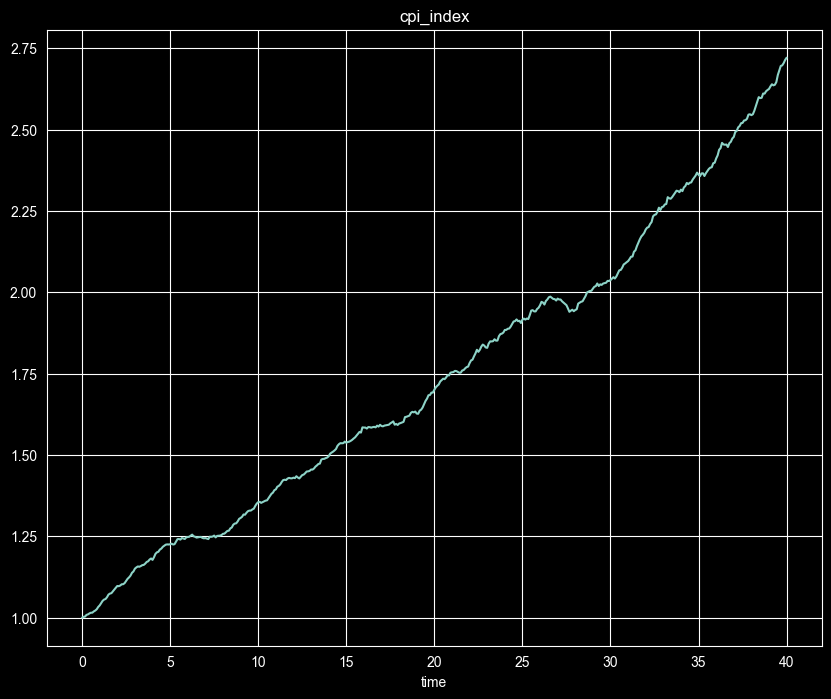

In [181]:
"""
Visualize variables
"""

idx_name = 'cpi_index'

fig, ax = plt.subplots(figsize = (10,8))

df_data[idx_name].plot(ax=ax)

ax.set_title(idx_name);


In [182]:
"""
Compounded inflation rate around 2.5%
"""

df_data['cpi_index'].values[-1]**(1 / 40) - 1

np.float64(0.025343316985993347)

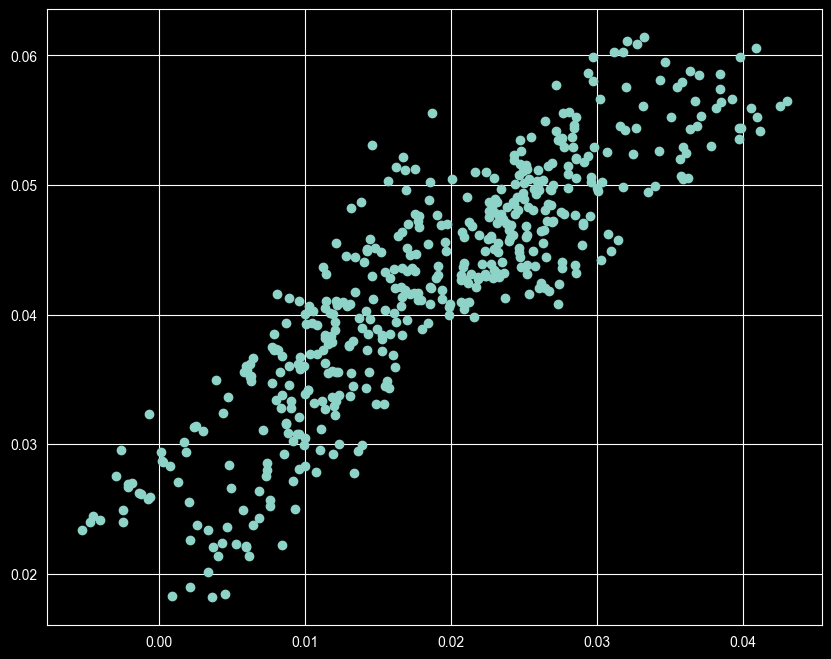

In [183]:
"""
Scatter plot between nominal and real yield for specific tenor
"""

tenor = 10

fig, ax = plt.subplots(figsize = (10,8))
ax.scatter(df_data['real_yield_{}y'.format(tenor)], df_data['nominal_yield_{}y'.format(tenor)])





## Modelling the term structure of interest rates


The difference between the real and nominal yield is known as the "break-even" inflation (BEIR) which we can think of as a market-based inflation expectation. A natural starting point for modelling the term structure dynamics is to model the real rate and the BEIR and construct the nominal yield by adding the two components.


The data is generated using a Diebold-Li type term structure model with three factors for respectively real yields and BEIR. I estimate the "true" model using the available data. The good project argues using e.g. PCA for the specific modeling choice.

In [184]:
"""
Select yields and calculate BEIR
"""

# tenor / maturities to model
tenors = np.array([1, 2, 3, 5, 7, 10, 15, 20])

# define nominal yields
nom_yields = df_data.loc[:, ['nominal_yield_{}y'.format(y) for y in tenors]]
# real yields
real_yields = df_data.loc[:, ['real_yield_{}y'.format(y) for y in tenors]]
# break evens
beir = nom_yields.values - real_yields.values

In [185]:
"""
We note that the one year break-even is close to the compounded inflation rate
"""

beir.mean(axis=0)

array([0.02617823, 0.02149982, 0.02018332, 0.02080594, 0.0221443 ,
       0.02367279, 0.02503359, 0.02573279])

### Helper functions for estimating Diebold-Li model

In [186]:
def calculate_slope(time_to_maturity: Union[float, np.ndarray], l: float):
    return (1 - np.exp(-time_to_maturity * l)) / (time_to_maturity * l)


def calculate_curvature(time_to_maturity: Union[float, np.ndarray], l: float):
    return (1 - np.exp(-time_to_maturity * l)) / (time_to_maturity * l) - np.exp(-(time_to_maturity * l))


def ols_ns(observed_yields: np.ndarray, tenors: np.ndarray, l):
    x_mat = np.c_[np.ones_like(tenors),
    calculate_slope(tenors, l),
    calculate_curvature(tenors, l)]

    est_params = np.linalg.lstsq(x_mat, observed_yields, rcond=None)

    return est_params[0]

In [187]:
def pricing_error(observed_yields: np.ndarray, tenors: np.ndarray, l):

    # get estimated parameters for fixed lambda
    betas = np.apply_along_axis(ols_ns, 1, observed_yields, tenors, l)

    # calculate loadings for fitted yields
    x_mat = np.c_[np.ones_like(tenors), calculate_slope(tenors, l), calculate_curvature(tenors, l)]

    # calculate fitted yields
    fitted_yields = betas @ x_mat.T

    # pricing error
    pricing_error = np.linalg.norm(observed_yields - fitted_yields)

    return pricing_error


### Fit Nelson-Siegel curves for real yields

For a fixed $\lambda$, we can estimate parameters using ordinary least squares. First, we get an idea of what lambda value is suitable by simply trying a range of different values and comparing the pricing error. 

In [188]:
# perform estimation for different values of lambda
test_lam = np.linspace(0.3, 1.3, 50)

# calculate the pricing error
pricing_errors = [pricing_error(real_yields.values, tenors, l) for l in test_lam]

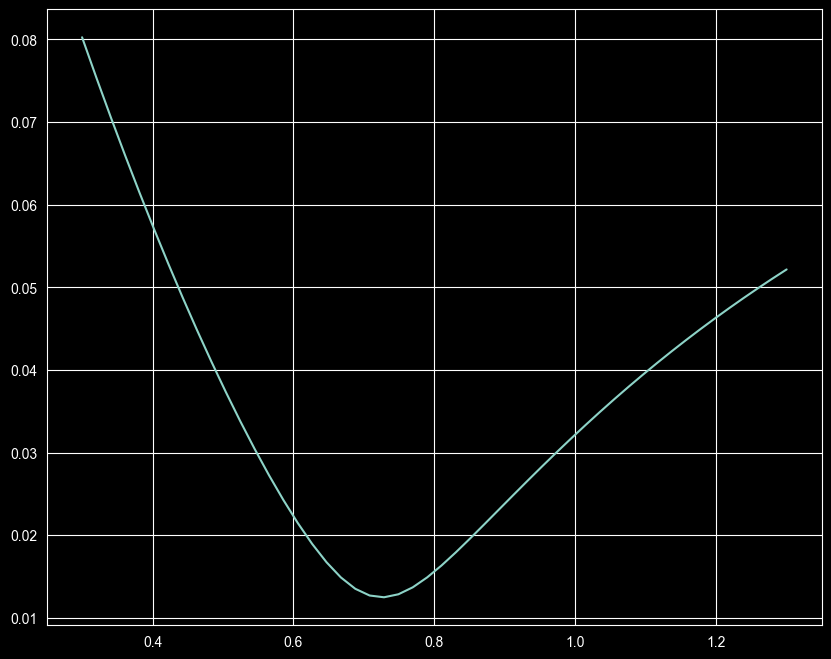

In [189]:
# plot pricing error
fig, ax  = plt.subplots(figsize = (10,8))
ax.plot(test_lam, pricing_errors);

In [190]:
"""
Optimal lambda for minimizing in-sample pricing error
"""

idx_min = np.argmin(pricing_errors)
test_lam[idx_min]

np.float64(0.7285714285714285)

Now, we estimate parameters for a chosen value of lambda

In [191]:
# fix lambda to specific value
lam_real = 0.72

# beta parameters for real yields
betas_real = np.apply_along_axis(ols_ns, 1, real_yields.values, tenors, lam_real)

### Fit Nelson-Siegel curves for break-evens

In [192]:
# perform estimation for different values of lambda
test_lam = np.linspace(0.3, 1.3, 50)

# calculate the pricing error
pricing_errors = [pricing_error(beir, tenors, l) for l in test_lam]

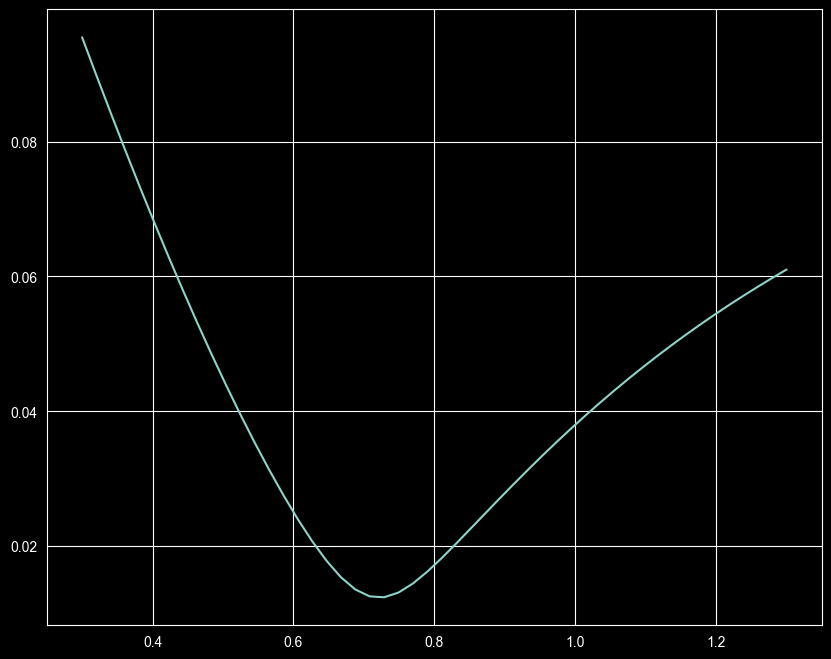

In [193]:
# plot pricing error
fig, ax  = plt.subplots(figsize = (10,8))
ax.plot(test_lam, pricing_errors);

In [194]:
idx_min = np.argmin(pricing_errors)
test_lam[idx_min]

np.float64(0.7285714285714285)

In [195]:
# fix lambda to specific value
lam_beir = 0.72

# beta parameters for real yields
betas_beir = np.apply_along_axis(ols_ns, 1, beir, tenors, lam_beir)

In [196]:
"""
Combine estimated betas for real and beir
"""

# combine real and beir betas
betas_joint = np.concatenate((betas_real, betas_beir), axis=1)

# create data frame
df_betas_joint = pd.DataFrame(data=betas_joint, columns=['beta1 real', 'beta2 real', 'beta3 real', 'beta1 beir', 'beta2 beir', 'beta3 beir'])

### Modelling time series dynamics of factors

We assume that the beta coefficients (factors) follow univariate AR(1) models. The student should argue for the specific type of model used.

The error terms of the regression models are the "market invariants".

AR(1) results for beta1 real:
                               SARIMAX Results                                
Dep. Variable:             beta1 real   No. Observations:                  481
Model:                 ARIMA(1, 0, 0)   Log Likelihood                2314.201
Date:                Mon, 23 Mar 2026   AIC                          -4622.402
Time:                        23:04:50   BIC                          -4609.874
Sample:                             0   HQIC                         -4617.478
                                - 481                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0221      0.005      4.601      0.000       0.013       0.032
ar.L1          0.9811      0.009    107.518      0.000       0.963       0.999
sigma2      3.851e-06 

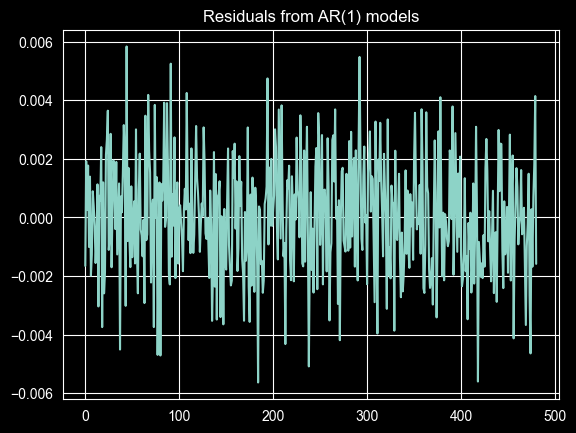

In [197]:
"""
Estimate seperate AR(1) models for each factor
"""

# dictionary to hold results
ar_results_dict = {}

# fit AR(1) models
for column in df_betas_joint.columns:
    ar_model = sm.tsa.ARIMA(df_betas_joint[column], order=(1, 0, 0))
    ar_results = ar_model.fit(method="innovations_mle")   # method_kwargs={'maxiter': 2000},
    ar_results_dict[column] = ar_results
    print(f"AR(1) results for {column}:")
    print(ar_results.summary())

# create a dataframe with parameter estimates
ar_params_df = pd.DataFrame({col: ar_results_dict[col].params for col in df_betas_joint.columns})
#print("AR(1) parameter estimates:")
print(ar_params_df)

# create a dataframe with fitted residuals
df_invariants = pd.DataFrame({col: ar_results_dict[col].resid for col in df_betas_joint.columns})

df_invariants['beta1 real'].plot(title='Residuals from AR(1) models')

df_invariants.corr().to_clipboard()

In [198]:
"""
Market invariants
"""

df_invariants

,beta1 real,beta2 real,beta3 real,beta1 beir,beta2 beir,beta3 beir
0,-0.001653,0.011293,-0.017527,-0.003109,-0.007886,0.015833
1,0.001915,-0.003891,0.002282,0.000549,0.000247,-0.010868
2,0.000253,-0.021887,0.033423,0.000807,0.011641,-0.017671
3,0.001769,-0.007381,-0.015355,-0.000097,0.017796,-0.006480
4,-0.001009,0.018948,-0.021887,-0.002500,-0.009632,0.002751
...,...,...,...,...,...,...
476,-0.001680,0.000500,-0.006946,-0.000698,-0.009063,0.019090
477,0.000682,0.016815,-0.014408,-0.000018,-0.013724,0.009206
478,0.001813,0.015202,-0.015281,-0.002174,-0.017142,0.017604
479,0.004140,-0.008067,0.011888,-0.001499,0.000296,0.003935


## Other market variables

### Modelling inflation

Break-even inflation is probably related to the expected inflation. We regress realized inflation on one year break-even inflation which is a measure of the market based inflation expectation

In [199]:
"""
The weakly log growth of the inflation index is modelled af 1/12 of initial BEIR + normal error term
"""

1 / 12

0.08333333333333333

In [200]:
# define variables in regression
realized_inflation = np.log(df_data['cpi_index']).diff().dropna().values # monthly realized inflation
beir_1y_lagged = beir[:-1, 0] # 1y beir lagged

# run regression
x_mat = sm.add_constant(beir_1y_lagged)  # Adds intercept
model = sm.OLS(realized_inflation, x_mat).fit()
print(model.summary())

 # Adds intercept
model_no_constant = sm.OLS(realized_inflation, beir_1y_lagged).fit()
print(model_no_constant.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.143
Model:                            OLS   Adj. R-squared:                  0.142
Method:                 Least Squares   F-statistic:                     79.98
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           8.31e-18
Time:                        23:04:52   Log-Likelihood:                 2199.7
No. Observations:                 480   AIC:                            -4395.
Df Residuals:                     478   BIC:                            -4387.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001      0.000      0.475      0.6

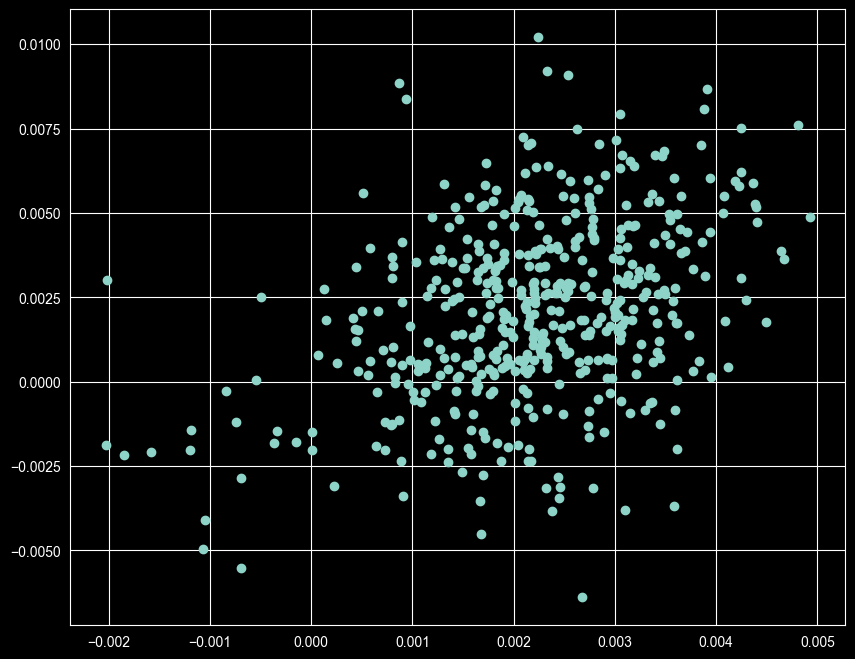

In [201]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(beir_1y_lagged / 12, realized_inflation)

The coefficient on 1y beir is very close to the time step 1 / 12, why we model the inflation as $\textit{beir 1y} / 12$ + noise. The noise seems to be normally distributed from the regression output. 

In [202]:
df_invariants['real. infl'] = np.nan
df_invariants.loc[1:, 'real. infl'] = realized_inflation - beir_1y_lagged / 12

In [203]:
df_invariants.head()

,beta1 real,beta2 real,beta3 real,beta1 beir,beta2 beir,beta3 beir,real. infl
0,-0.001653,0.011293,-0.017527,-0.003109,-0.007886,0.015833,NaN
1,0.001915,-0.003891,0.002282,0.000549,0.000247,-0.010868,0.000895
2,0.000253,-0.021887,0.033423,0.000807,0.011641,-0.017671,-0.000733
3,0.001769,-0.007381,-0.015355,-0.000097,0.017796,-0.006480,0.002967
4,-0.001009,0.018948,-0.021887,-0.002500,-0.009632,0.002751,-0.001531


### Modelling cost inflation

In [204]:
# define cost inflation
# define variables in regression
realized_cost_inflation = np.log(df_data['real_estate_cost_index']).diff().dropna().values # monthly realized inflation

# run regression
x_mat = sm.add_constant(realized_inflation)  # Adds intercept
model = sm.OLS(realized_cost_inflation, x_mat).fit()
print(model.summary())

 # Adds intercept
model_no_constant = sm.OLS(realized_cost_inflation, realized_inflation).fit()
print(model_no_constant.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.521
Model:                            OLS   Adj. R-squared:                  0.520
Method:                 Least Squares   F-statistic:                     519.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           2.31e-78
Time:                        23:04:53   Log-Likelihood:                 2205.8
No. Observations:                 480   AIC:                            -4408.
Df Residuals:                     478   BIC:                            -4399.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002      0.000      1.078      0.2

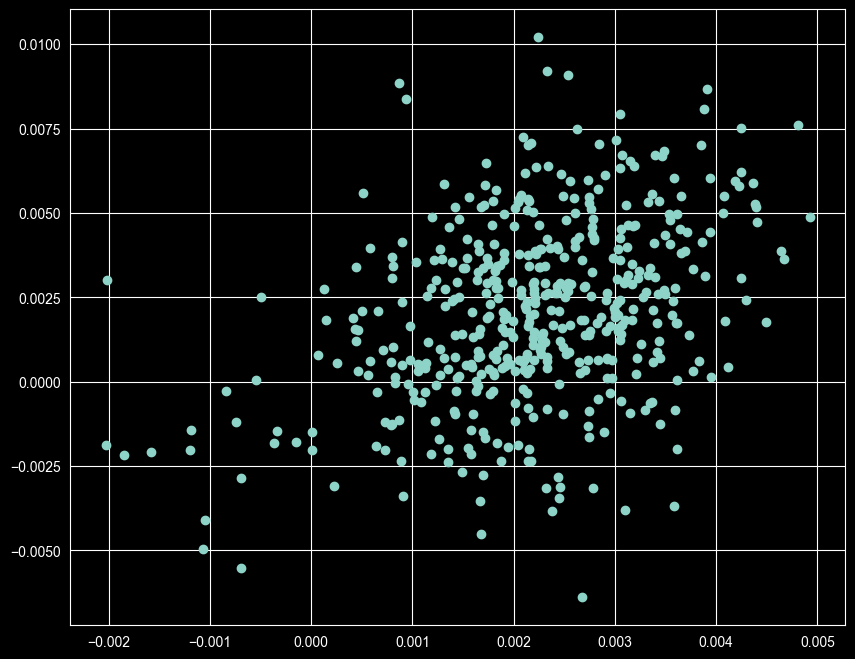

In [205]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(beir[:-1, 0]/12, np.log(df_data['cpi_index']).diff().dropna())

It seems that we can model cost inflation as inflation + noise

In [206]:
df_invariants['real. cost infl'] = np.nan
df_invariants.loc[1:, 'real. cost infl'] = realized_cost_inflation - realized_inflation


### Model rental "inflation"

In [207]:
# define cost inflation
# define variables in regression
realized_rent_inflation = np.log(df_data['real_estate_rent_index']).diff().dropna().values # monthly realized inflation

# run regression
x_mat = sm.add_constant(realized_inflation)  # Adds intercept
model = sm.OLS(realized_rent_inflation, x_mat).fit()
print(model.summary())

 # Adds intercept
model_no_constant = sm.OLS(realized_rent_inflation, realized_inflation).fit()
print(model_no_constant.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.478
Model:                            OLS   Adj. R-squared:                  0.477
Method:                 Least Squares   F-statistic:                     438.3
Date:                Mon, 23 Mar 2026   Prob (F-statistic):           1.50e-69
Time:                        23:04:53   Log-Likelihood:                 2168.8
No. Observations:                 480   AIC:                            -4334.
Df Residuals:                     478   BIC:                            -4325.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0011      0.000      7.255      0.0

Again, inflation + noise. However, it seems to be important to model a approx. 10 bps above inflation monthly rental increase.

In [208]:
df_invariants['real. rent infl'] = np.nan
df_invariants.loc[1:, 'real. rent infl'] = realized_rent_inflation - realized_inflation

### Model equity dynamics

We model equity log return using a normal distribution. Thus, the log return is just our invariant. The student should check for autocorrelation, etc. 

In [209]:
df_invariants.loc[1:, 'log ret equity'] = np.log(df_data['equity_index']).diff().dropna().values

### Model invariant distribution

We specified models for all risk drivers and defined invariants. It is important model potential correlation between the market invariants.

The invariants will follow a multivariate normal distribution, see e.g. the individual tests in the above regression. The student should test this.

In [210]:
df_invariants = df_invariants.dropna()

In [211]:
# number of invariants
num_invariants = df_invariants.shape[1]

# expected invariants
mu_invariants = np.zeros(num_invariants)
mu_invariants[-2] = df_invariants['real. rent infl'].mean()
mu_invariants[-1] = df_invariants['log ret equity'].mean()

# volatility of invariants
vol_invariants = df_invariants.std().values

# correlation invariants
corr_mat_invariants = df_invariants.corr().values

# covariance matrix invariants
cov_mat_invariants = np.diag(vol_invariants) @ corr_mat_invariants @ np.diag(vol_invariants)

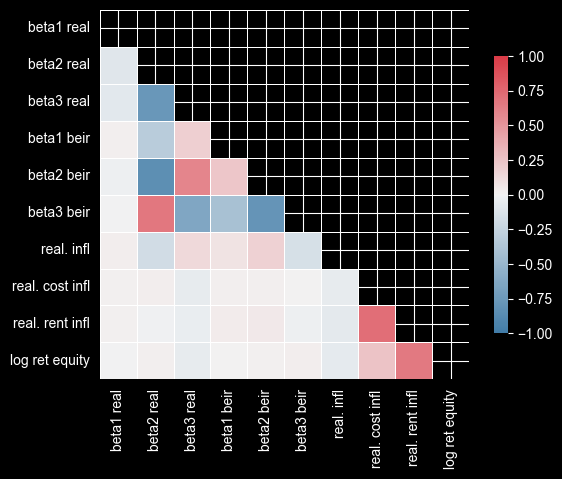

In [212]:
"""
Plot correlation matrix using heat map
"""

correlation_plot(corr_mat_invariants, names=df_invariants.columns)



In [213]:
mu_invariants

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.00099643, 0.00546214])

## Simulate the market over the next 20 years

In [214]:
# general settings
num_sim = 10_000 # number of simulations
dt = 1 / 12 # time step
horizon = 20 # years
num_time_steps = int(horizon / dt) # number of monthly time steps

time_points = np.arange(num_time_steps + 1) * dt


# simulate panel of market invariants
simulated_invariants = multivariate_normal.rvs(mean=mu_invariants,
                                               cov=cov_mat_invariants,
                                               size=(num_time_steps, num_sim))


# define dictionary to hold simulated variables
esg = {} # economic scenario generator

In [215]:
simulated_invariants.shape

(240, 10000, 10)

### Simulate AR(1) factors

In [216]:
def simulate_multiple_ar_process(mu: np.ndarray,
                                 phi: np.ndarray,
                                 initial_values: np.ndarray,
                                 shocks: np.ndarray = None) -> np.ndarray:

    # number of simulation
    num_sim = shocks.shape[1]

    # number of time steps
    num_periods = shocks.shape[0]

    sim_data = np.zeros((num_periods + 1, num_sim, len(mu)))
    sim_data[0, :, :] = initial_values

    # simulate AR(1) processes
    for t in range(0, num_periods):
        sim_data[t + 1, :, :] = mu + phi * (sim_data[t, :, :] - mu) + shocks[t , :, :]

    return sim_data

In [217]:
# mu, phi, sigma
mu_factors = ar_params_df.loc['const', :].values
phi_factors = ar_params_df.loc['ar.L1', :].values

# initial values
initial_values = df_betas_joint.iloc[-1, :].values

# simulate factors
beta_sim = simulate_multiple_ar_process(mu=mu_factors,
                                        phi=phi_factors,
                                        initial_values=initial_values,
                                        shocks=simulated_invariants[:, :, :6])

# store in esg dict
esg['BETA1_REAL'] = beta_sim[:, :, 0].T
esg['BETA2_REAL'] = beta_sim[:, :, 1].T
esg['BETA3_REAL'] = beta_sim[:, :, 2].T
esg['BETA1_BEIR'] = beta_sim[:, :, 3].T
esg['BETA2_BEIR'] = beta_sim[:, :, 4].T
esg['BETA3_BEIR'] = beta_sim[:, :, 5].T

### Generate yield curves from simulated factors

In [218]:
# set maturities for yield curves to simulate
maturities = np.arange(1, 21, 1) # in years

In [219]:
"""
Simulate yield curve factors
"""

# calculate slope and curvature loadings
real_slope_loadings = calculate_slope(maturities, lam_real)
real_curvature_loadings = calculate_curvature(maturities, lam_real)

# calculate real yields using Nelson-Siegel model, add some random noise
sim_real_yields = esg['BETA1_REAL'][:, :, np.newaxis] + \
                  esg['BETA2_REAL'][:, :, np.newaxis] * real_slope_loadings[np.newaxis, np.newaxis, :] + \
                  esg['BETA3_REAL'][:, :, np.newaxis] * real_curvature_loadings[np.newaxis, np.newaxis, :]  # we drop noise for simplicity, but it can be added as well


# calculate slope and curvature loadings
beir_slope_loadings = calculate_slope(maturities, lam_beir)
beir_curvature_loadings = calculate_curvature(maturities, lam_beir)

# calculate beir using Nelson-Siegel model, add some random noise
sim_beir = esg['BETA1_BEIR'][:, :, np.newaxis] + \
           esg['BETA2_BEIR'][:, :, np.newaxis] * beir_slope_loadings[np.newaxis, np.newaxis, :] + \
           esg['BETA3_BEIR'][:, :, np.newaxis] * beir_curvature_loadings[np.newaxis, np.newaxis, :]


# calculate nominal yields
sim_nom_yields = sim_real_yields + sim_beir

In [220]:
"""
Store in ESG dict
"""

for i, maturity in enumerate(maturities):
    esg[f'REAL_YIELD_{maturity}Y'] = sim_real_yields[:, :, i]
    esg[f'BEIR_{maturity}Y'] = sim_beir[:, :, i]
    esg[f'NOMINAL_YIELD_{maturity}Y'] = sim_nom_yields[:, :, i]


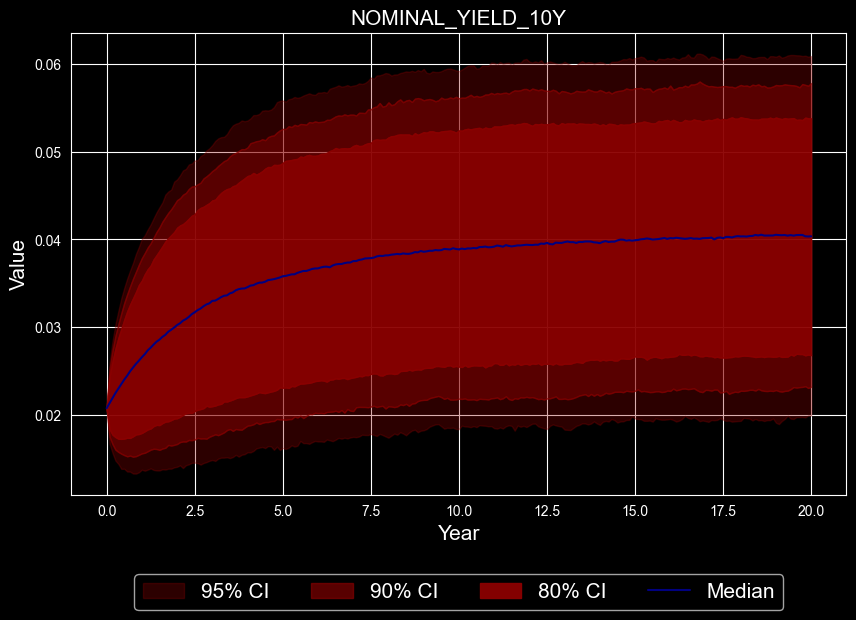

In [221]:
# calculate percentiles
ticker = 'NOMINAL_YIELD_10Y'
percentiles = np.percentile(esg[ticker], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title(ticker, size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

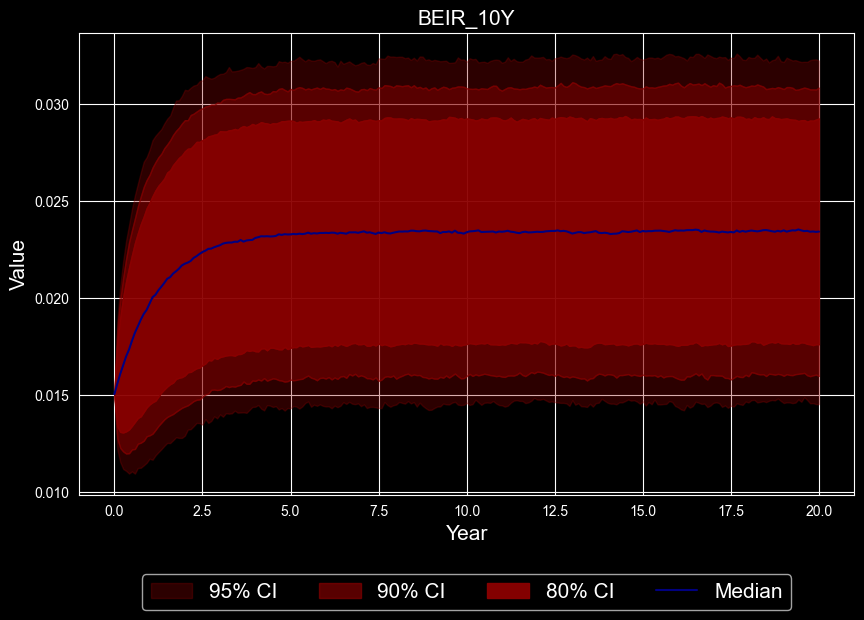

In [222]:
# calculate percentiles
ticker = 'BEIR_10Y'
percentiles = np.percentile(esg[ticker], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title(ticker, size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

### Simulate other market variables

In [223]:
# inflation
esg['INFLATION'] = np.zeros_like(esg['BEIR_1Y'])
esg['INFLATION'][:, 1:] = esg['BEIR_1Y'][:, :-1] * dt + simulated_invariants[:, :, 6].T

esg['CPI_INDEX'] = np.exp(np.cumsum(esg['INFLATION'], axis=1))

# cost inflation
esg['COST_INFLATION'] = esg['INFLATION'].copy()
esg['COST_INFLATION'][:, 1:] += simulated_invariants[:, :, 7].T
esg['COST_INDEX'] = np.exp(np.cumsum(esg['COST_INFLATION'], axis=1))

# rental inflation
esg['RENT_INFLATION'] = esg['INFLATION'].copy()
esg['RENT_INFLATION'][:, 1:] += simulated_invariants[:, :, 8].T
esg['RENT_INDEX'] = np.exp(np.cumsum(esg['RENT_INFLATION'], axis=1))

# equity returns
esg['EQUITY_LOG_RET'] = np.zeros_like(esg['BEIR_1Y'])
esg['EQUITY_LOG_RET'][:, 1:] = simulated_invariants[:, :, 9].T
esg['EQUITY_INDEX'] = np.exp(np.cumsum(esg['EQUITY_LOG_RET'], axis=1))

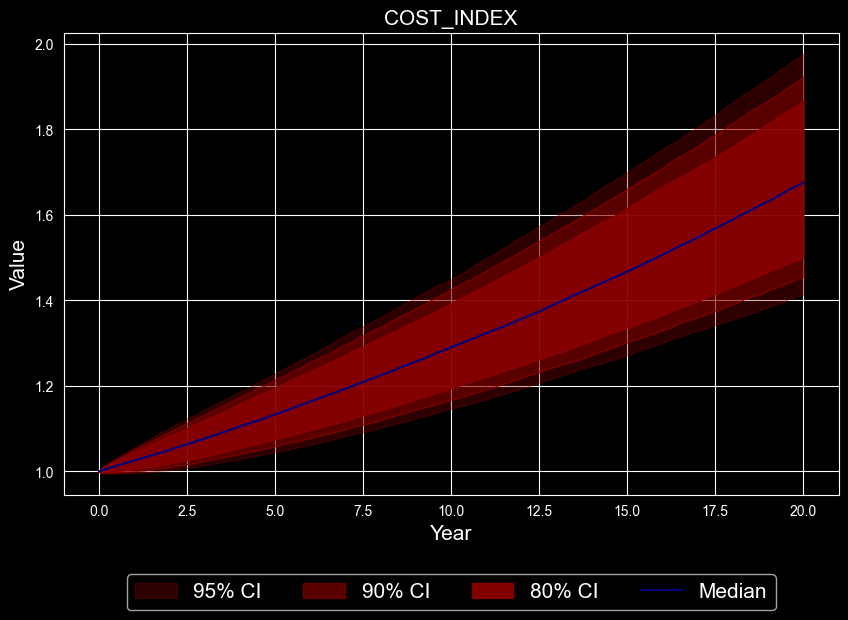

In [224]:
# calculate percentiles
ticker = 'COST_INDEX'
percentiles = np.percentile(esg[ticker], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title(ticker, size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

### Simulate the value of a 10y constant maturity bond strategy

Simulate the value of a strategy that invests in a 10y constant maturity bond. We assume that the strategy is rebalanced monthly, thus we need to calculate the price of a 10y zero coupon bond at each time step and for each simulation. We can use the Nelson-Siegel model to calculate the price of the bond from the simulated factors.

In [225]:
# calculate real yields using Nelson-Siegel model, add some random noise
sim_real_yields_ = esg['BETA1_REAL'] + \
                  esg['BETA2_REAL'] * calculate_slope(10 - dt, lam_real)+ \
                  esg['BETA3_REAL'] * calculate_curvature(10 - dt, lam_real)  # we drop noise for simplicity, but it can be added as well

# calculate beir using Nelson-Siegel model, add some random noise
sim_beir_ = esg['BETA1_BEIR'] + \
           esg['BETA2_BEIR'] * calculate_slope(10 - dt, lam_beir) + \
           esg['BETA3_BEIR'] * calculate_curvature(10 - dt, lam_beir)


# calculate nominal yields
sim_nom_yield_ = sim_real_yields_ + sim_beir_

In [226]:
sim_nom_yields.shape

(10000, 241, 20)

In [227]:
esg['NOMINAL_YIELD_10Y']

array([[0.02075759, 0.01813784, 0.01871972, ..., 0.0524979 , 0.05379046,
        0.04963817],
       [0.02075759, 0.01929502, 0.0151912 , ..., 0.04175946, 0.04225594,
        0.04014273],
       [0.02075759, 0.02294131, 0.02508732, ..., 0.02849863, 0.02981989,
        0.02933486],
       ...,
       [0.02075759, 0.02114022, 0.01976615, ..., 0.03338955, 0.03423322,
        0.03349121],
       [0.02075759, 0.02150142, 0.0203725 , ..., 0.02996699, 0.03391327,
        0.0364935 ],
       [0.02075759, 0.02069759, 0.01940903, ..., 0.05017091, 0.04778425,
        0.04532001]], shape=(10000, 241))

In [228]:
# price of a 10y zero coupon bond
price_zcb_10y = np.exp(-10*esg['NOMINAL_YIELD_10Y'])
esg['ZCB_10Y_PRICE'] = price_zcb_10y

# price of a 9y and 11 month zero coupon bond
price_zcb_10y_next_step = np.exp(-(10 - dt)* sim_nom_yield_)

# return
esg['ZCB_10Y_RET'] = np.zeros_like(esg['BEIR_1Y'])
esg['ZCB_10Y_RET'][:, 1:] = price_zcb_10y_next_step[:, 1:] / price_zcb_10y[:, :-1] - 1

# CM strategy return
esg['CM_10Y_PRICE'] = np.cumprod(1 + esg['ZCB_10Y_RET'], axis=1)

In [229]:
esg['ZCB_10Y_RET']

array([[ 0.        ,  0.02872258, -0.00351042, ...,  0.01988518,
        -0.00780706,  0.04717499],
       [ 0.        ,  0.01721061,  0.04400586, ..., -0.0058238 ,
        -0.00045064,  0.02591929],
       [ 0.        , -0.01905956, -0.0185001 , ...,  0.00041517,
        -0.01007683,  0.00798987],
       ...,
       [ 0.        , -0.00147838,  0.01612807, ..., -0.0115947 ,
        -0.0044236 ,  0.01151973],
       [ 0.        , -0.0052038 ,  0.01358746, ...,  0.00670045,
        -0.03519451, -0.02187424],
       [ 0.        ,  0.00285252,  0.01499719, ...,  0.01389114,
         0.02907892,  0.02938909]], shape=(10000, 241))

In [230]:
esg['CM_10Y_PRICE']

array([[1.        , 1.02872258, 1.02511133, ..., 1.97024395, 1.95486214,
        2.04708275],
       [1.        , 1.01721061, 1.06197383, ..., 1.95509942, 1.95421837,
        2.00487031],
       [1.        , 0.98094044, 0.96279294, ..., 2.23271047, 2.21021181,
        2.22787113],
       ...,
       [1.        , 0.99852162, 1.01462585, ..., 1.86759054, 1.85932906,
        1.88074804],
       [1.        , 0.9947962 , 1.00831296, ..., 2.3207653 , 2.2390871 ,
        2.19010876],
       [1.        , 1.00285252, 1.01789249, ..., 1.77859016, 1.83030965,
        1.88410078]], shape=(10000, 241))

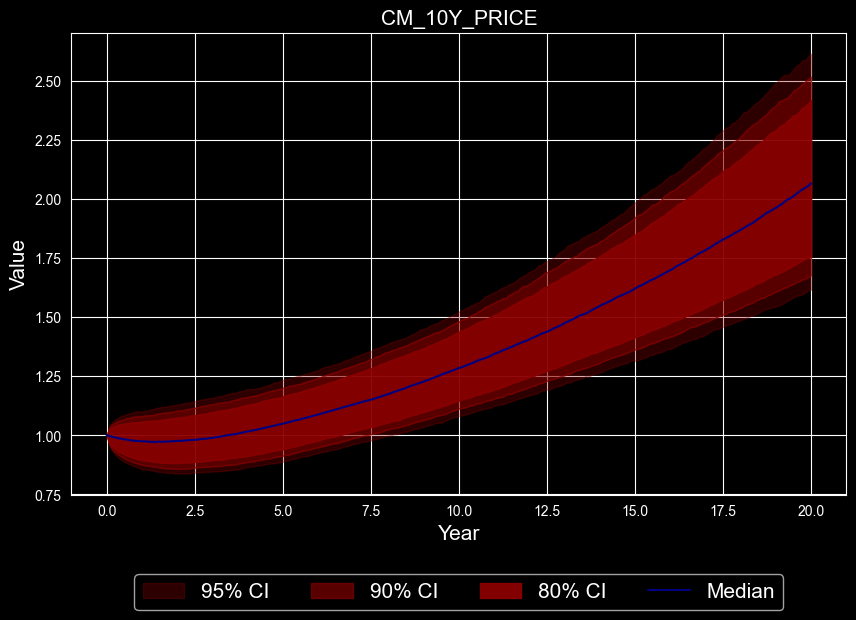

In [231]:
# calculate percentiles
ticker = 'CM_10Y_PRICE'
percentiles = np.percentile(esg[ticker], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title(ticker, size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

### Simulate value of initial portfolio

In [232]:
wealth = 1_000_000_000 # initial wealth

# initial portfolio weights
w_equity = 0.4
w_bond = 1 - w_equity

# portfolio value over time
esg['INIT_PORT_VALUE'] = wealth * (w_bond * esg['CM_10Y_PRICE'] + w_equity * esg['EQUITY_INDEX'])


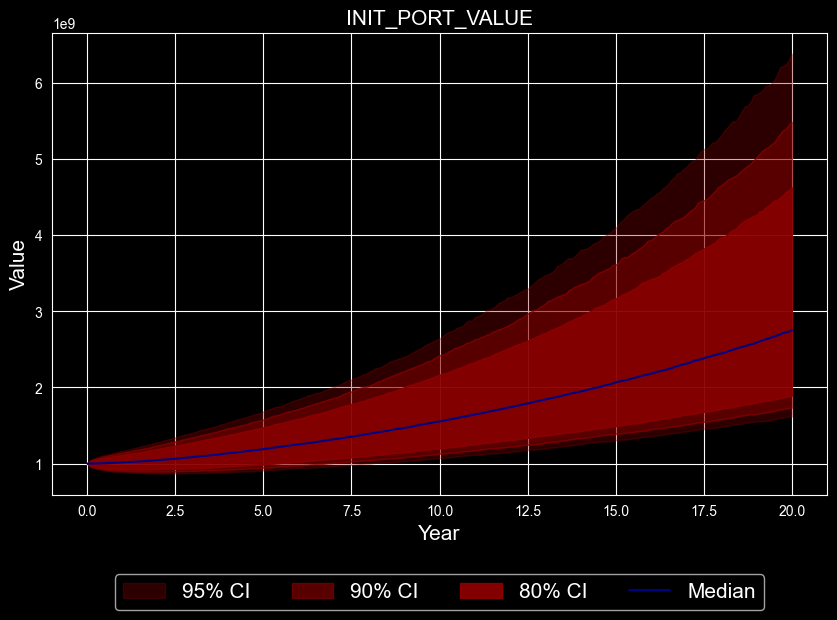

In [233]:
# calculate percentiles
ticker = 'INIT_PORT_VALUE'
percentiles = np.percentile(esg[ticker], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title(ticker, size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

## Real Estate Investment Analysis

A simple cash flow model is construct. The students are welcome to introduce more detail in the modeling of the real estate investment.

### Define parameters for real estate investment

In [234]:
price = 400_000_000 # initial price of the real estate investment

num_rental_units = 100 # number of rental units
avg_rental_unit_size = 100 # average size of rental unit in sqm

init_rent_per_sqm = 2000 # initial rent per sqm, per year
init_market_rent_per_sqm = 2200 # initial market rent per sqm, per year

churn = 0.2 # annual tenant churn rate. Could be made stochastic as well, but we keep it constant for simplicity.

init_opex = 3_000_000 # initial operating expenses per year

fixed_cost_renovation = 12500 # per rental unit, per renovation
variable_cost_renovation = 100 # per sqm, per renovation

vacancy = 2 / 100 # vacancy rate

In [235]:
year_idx = [0, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120, 132, 144, 156, 168, 180, 192, 204, 216, 228, 240]

yearly_time_points = np.array(year_idx) * dt

In [236]:
esg['COST_INDEX'][:, year_idx].shape

(10000, 21)

### Simulate cash flows from real estate investment

We can simulate the cash flows from the real estate investment by simulating the rental income and operating expenses over time. We can also simulate the renovation costs based on the tenant churn and the size of the rental units.

The operational expenses can be modelled as a percentage of the rental income, or as a fixed amount that grows with inflation. For simplicity, we model it as a fixed amount that grows with the cost inflation. The rental income can be modelled as the product of the rent per sqm, the size of the rental units, and the number of rental units. The rent per sqm can be modelled as growing with the market rent per sqm, which in turn can be modelled as growing with the rental inflation. The renovation costs can be modelled as the product of the number of tenants that churn, the size of the rental units, and the fixed and variable renovation costs.

In [237]:
cpi_yearly = esg['CPI_INDEX'][:, year_idx]
rent_index_yearly = esg['RENT_INDEX'][:, year_idx]
cost_index_yearly = esg['COST_INDEX'][:, year_idx]

"""
Calculate rental income
"""


# calculate market rent per sqm
sim_market_rent_per_sqm = init_market_rent_per_sqm * rent_index_yearly

# calculate rent per sqm
sim_rent_per_sqm = np.zeros_like(sim_market_rent_per_sqm)
sim_rent_per_sqm[:, 0] = init_rent_per_sqm
for i, h in enumerate(year_idx[1:]):
    sim_rent_per_sqm[:, i+1] = sim_rent_per_sqm[:, i] * (1 - churn) * cpi_yearly[:, i + 1] / cpi_yearly[:, i] + \
                                            sim_market_rent_per_sqm[:, i + 1] * churn


sim_rental_income = sim_rent_per_sqm * avg_rental_unit_size * num_rental_units * (1 - vacancy)

"""
Operational expenditures (OPEX)
"""

sim_opex = init_opex * cost_index_yearly

"""
CAPEX
"""

sim_capex = np.zeros_like(sim_rental_income)
for i, h in enumerate(year_idx[1:]):
    sim_capex[:, i+1] = (num_rental_units * churn) * (fixed_cost_renovation + variable_cost_renovation * avg_rental_unit_size) * cost_index_yearly[:, i + 1]


"""
Calculate NOI (Net Operating Income) without CAPEX, as it is not part of the operational cash flows. We can use NOI to calculate the market value of the real estate investment at each time step, and then calculate the return on the investment over time.
"""

sim_noi = sim_rental_income - sim_opex  # exclude CAPEX
sim_noi[:, 0] = 0.0 # we assume that there are no cash flows in the first year, as the investment is made at time 0 and the first rental income is received at the end of the first year. This can be adjusted if we want to model cash flows more granularly (e.g., monthly), but for simplicity we keep it yearly.

"""
CASH FLOWS
"""

sim_cash_flows = sim_noi - sim_capex

In [238]:
sim_noi[:, 1].mean() / 400_000_000

np.float64(0.04368427482838679)

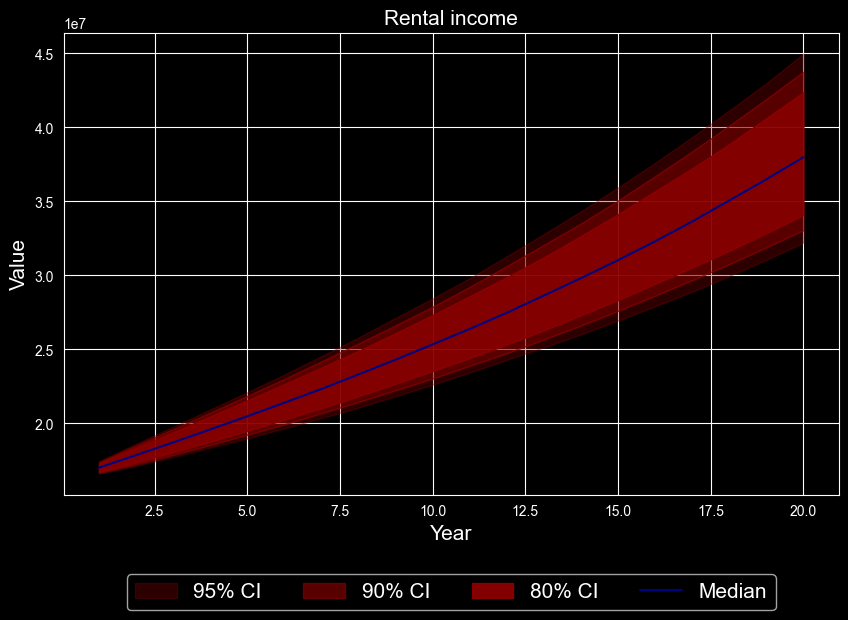

In [239]:
# calculate percentiles
percentiles = np.percentile(sim_cash_flows[:, 1:], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(yearly_time_points[1:],
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title("Rental income", size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

### Calculate approximate market values of the real estate investment

In [240]:
risk_premium = 350 / 10_000

"""
Calculate cap rate
"""

cap_rates = esg['REAL_YIELD_20Y'][:, year_idx] + risk_premium


"""
Calculate approximate market value of the real estate investment using the cap rate and the NOI
"""

sim_market_values = sim_noi / cap_rates

In [241]:
esg['REAL_YIELD_20Y'][:, 0] + risk_premium

array([0.04174055, 0.04174055, 0.04174055, ..., 0.04174055, 0.04174055,
       0.04174055], shape=(10000,))

In [242]:
# Cap rate as discrete rate
(sim_noi[:, 1] / (esg['REAL_YIELD_20Y'][:, 1] + risk_premium)).mean() / 1.03

np.float64(406045330.7465317)

In [243]:
sim_market_values.mean(axis=0)

array([0.00000000e+00, 4.07132634e+08, 4.13047792e+08, 4.18428231e+08,
       4.26186631e+08, 4.36324291e+08, 4.48455187e+08, 4.61289504e+08,
       4.75356247e+08, 4.90750176e+08, 5.08843269e+08, 5.26572083e+08,
       5.46280711e+08, 5.67474862e+08, 5.89138631e+08, 6.10760490e+08,
       6.33836582e+08, 6.58835359e+08, 6.84604609e+08, 7.12343309e+08,
       7.40348536e+08])

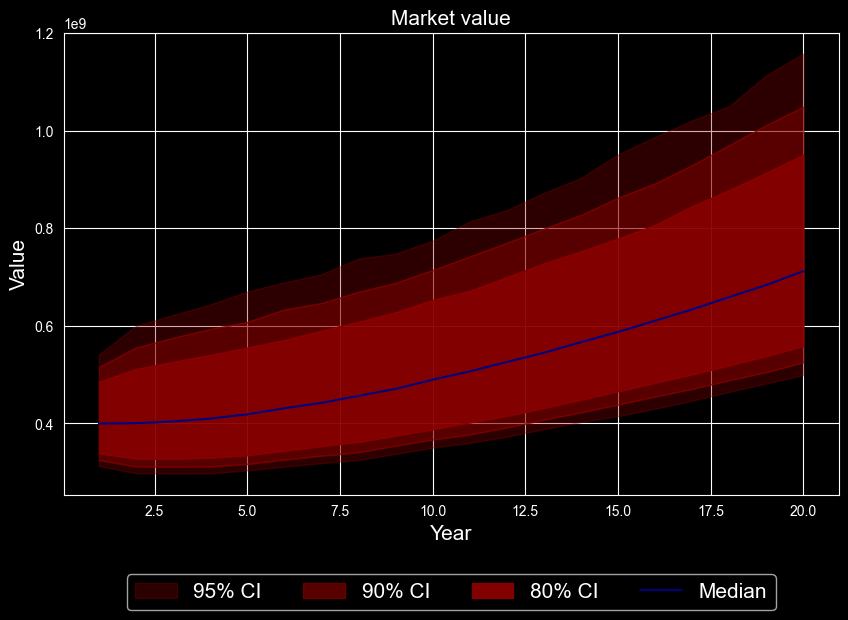

In [244]:
# calculate percentiles
percentiles = np.percentile(sim_market_values[:, 1:], [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(yearly_time_points[1:],
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title("Market value", size=15)

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

### Calculate IRR for the investment

In [245]:
horizon = 20
irr_values = np.zeros(num_sim)

for i in range(num_sim):
    # get cash flows for the scenario
    scenario_cash_flows = sim_cash_flows[i, :horizon].copy()

    # add terminal market value to the last cash flow
    terminal_value = sim_market_values[i, horizon - 1]
    scenario_cash_flows[-1] += terminal_value

    # create cash flow object for the scenario
    cash_flow_object = CashFlow(time_points=np.arange(1, horizon + 1), flows=scenario_cash_flows)

    # calculate IRR for the scenario
    irr_values[i] = cash_flow_object.internal_rate_of_return(price)



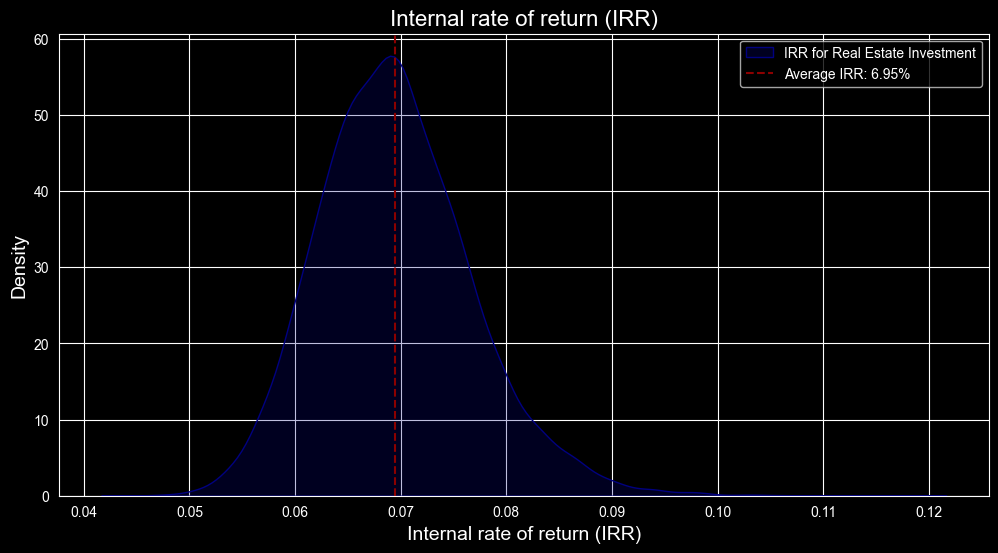

In [246]:
"""
Plot kernel density of IRR 10y
"""

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
sns.kdeplot(irr_values,
            fill=True,
            color='navy',
            label='IRR for Real Estate Investment',
            ax=ax)
# labels
ax.set_xlabel('Internal rate of return (IRR)')
ax.set_ylabel('Density')
ax.set_title('Internal rate of return (IRR)')


# increase font size for better readability
ax.title.set_fontsize(16)
ax.xaxis.label.set_fontsize(14)
ax.yaxis.label.set_fontsize(14)

# add mean line
mean_irr_20y = np.mean(irr_values)
ax.axvline(mean_irr_20y, color='darkred', linestyle='--', label='Average IRR: {:.2%}'.format(mean_irr_20y))
ax.legend()

In [247]:
mean_irr_20y

np.float64(0.06946773554157117)

### Total return index with reinvestment in one year bond

In [258]:
tri_real_estate = np.zeros_like(esg['INIT_PORT_VALUE'][:, year_idx])
tri_real_estate[:, 0] = price
one_year_bond_investment = 0.0

for i, h in enumerate(year_idx[1:]):
    one_year_bond_investment = one_year_bond_investment * np.exp(esg['NOMINAL_YIELD_1Y'][:, h]) +  sim_cash_flows[:, i + 1]
    tri_real_estate[:, i + 1] = sim_market_values[:, i + 1]  + one_year_bond_investment


In [265]:
"""
Geometric return at horizon
"""

avg_geo_20y = np.mean((tri_real_estate[:, -1] / tri_real_estate[:, 0])**(1 / horizon) - 1)
avg_geo_20y

np.float64(0.06509555423640366)

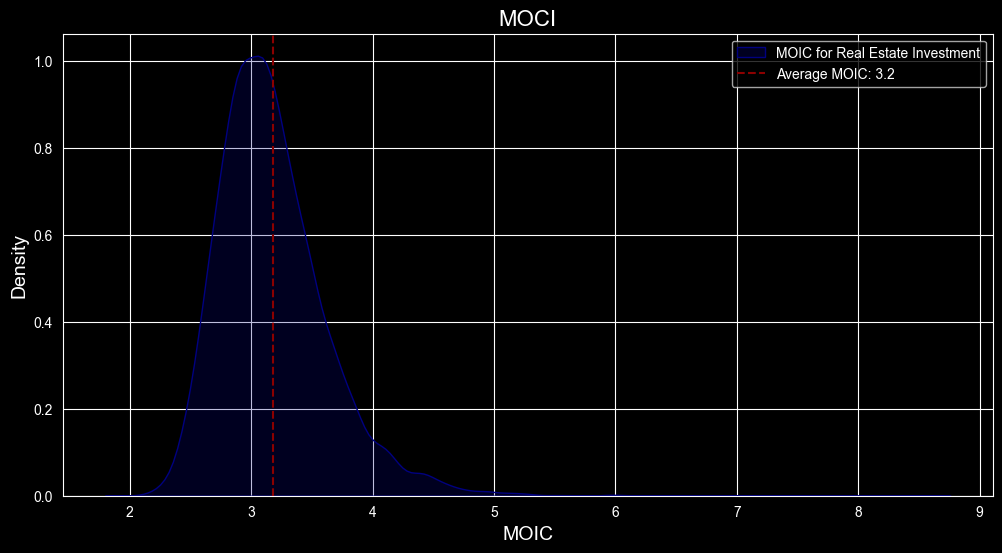

In [272]:
"""
MOIC
"""

moic = (sim_market_values[:, i + 1] + np.sum(sim_cash_flows, axis=1))/ tri_real_estate[:, 0]

"""
Plot kernel density of MOIC 20y
"""

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
sns.kdeplot(moic,
            fill=True,
            color='navy',
            label='MOIC for Real Estate Investment',
            ax=ax)
# labels
ax.set_xlabel('MOIC')
ax.set_ylabel('Density')
ax.set_title('MOCI')


# increase font size for better readability
ax.title.set_fontsize(16)
ax.xaxis.label.set_fontsize(14)
ax.yaxis.label.set_fontsize(14)

# add mean line
mean_moic_20y = np.mean(moic)
ax.axvline(mean_moic_20y, color='darkred', linestyle='--', label='Average MOIC: {:.2}'.format(mean_moic_20y))
ax.legend();

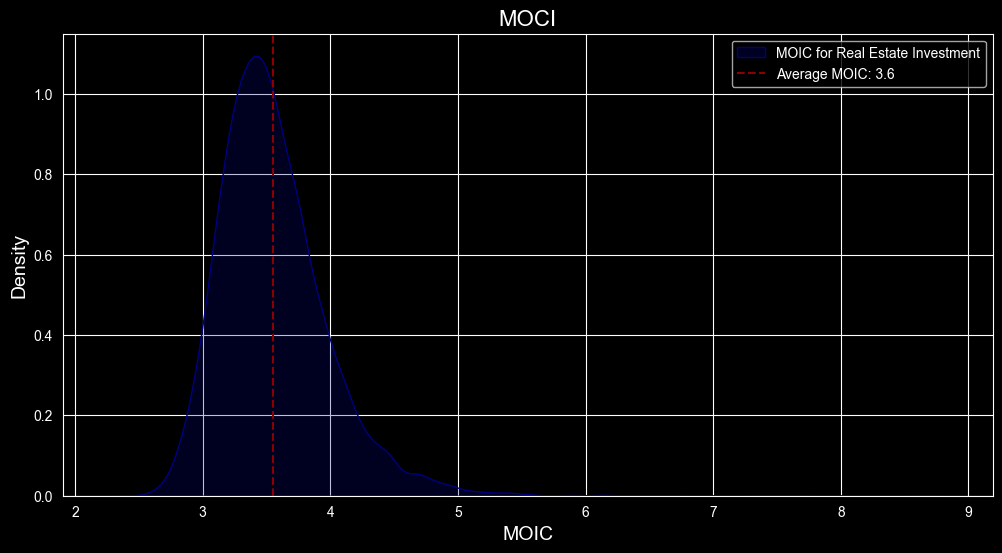

In [273]:

"""
MOIC with reinvestment in 1y bonds
"""

moic = tri_real_estate[:, -1] / tri_real_estate[:, 0]

"""
Plot kernel density of MOIC 20y
"""

fig, ax = plt.subplots()
fig.set_size_inches(12, 6)
sns.kdeplot(moic,
            fill=True,
            color='navy',
            label='MOIC for Real Estate Investment',
            ax=ax)
# labels
ax.set_xlabel('MOIC')
ax.set_ylabel('Density')
ax.set_title('MOCI')


# increase font size for better readability
ax.title.set_fontsize(16)
ax.xaxis.label.set_fontsize(14)
ax.yaxis.label.set_fontsize(14)

# add mean line
mean_moic_20y = np.mean(moic)
ax.axvline(mean_moic_20y, color='darkred', linestyle='--', label='Average MOIC: {:.2}'.format(mean_moic_20y))
ax.legend();

## Portfolio evaluation and risk analysis

The student should present relevant metrics and visualization, e.g.

- Plot the distribution of total return at the horizon
- Return and risk metrics
- Probability of beating initial portfolio
- Risk contribution

The real estate investment is generally a good add-on to the portfolio (abstracting from issues such a illiquidity)

In [277]:
# value of initial portfolio at the end of each year
init_port_value_yearly = esg['INIT_PORT_VALUE'][:, year_idx]

# normalize
tri_init_port = init_port_value_yearly / init_port_value_yearly[:, 0]

# calculate portfolio with investment - assume reinvestment of cash flows in one year bond
port_value_with_investment_yearly = esg['INIT_PORT_VALUE'][:, year_idx] * (wealth - price) / wealth + tri_real_estate

# normalize
tri_port_with_investment = port_value_with_investment_yearly / port_value_with_investment_yearly[:, 0]

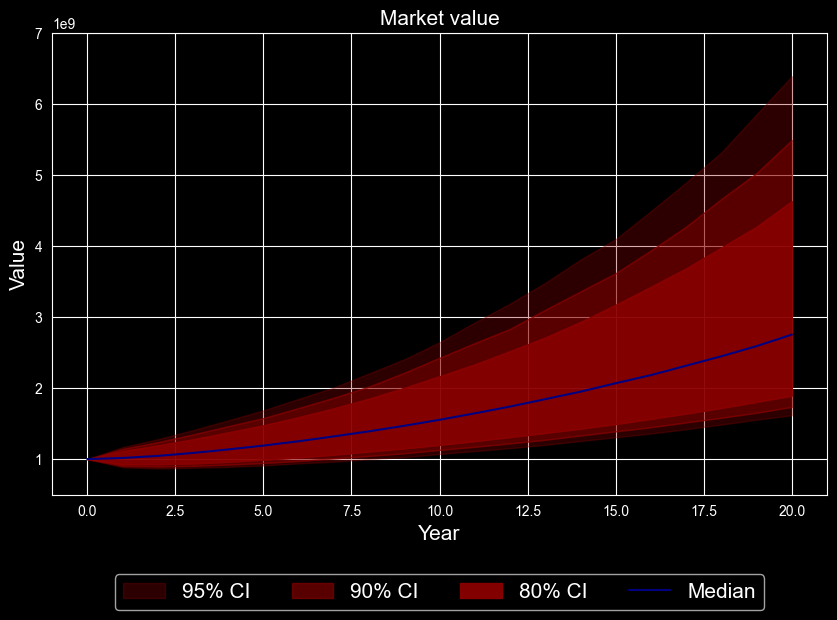

In [279]:
# calculate percentiles
percentiles = np.percentile(init_port_value_yearly, [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(yearly_time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title("Market value", size=15)
ax.set_ylim([500 * 1e6, 7_000 * 1e6])

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

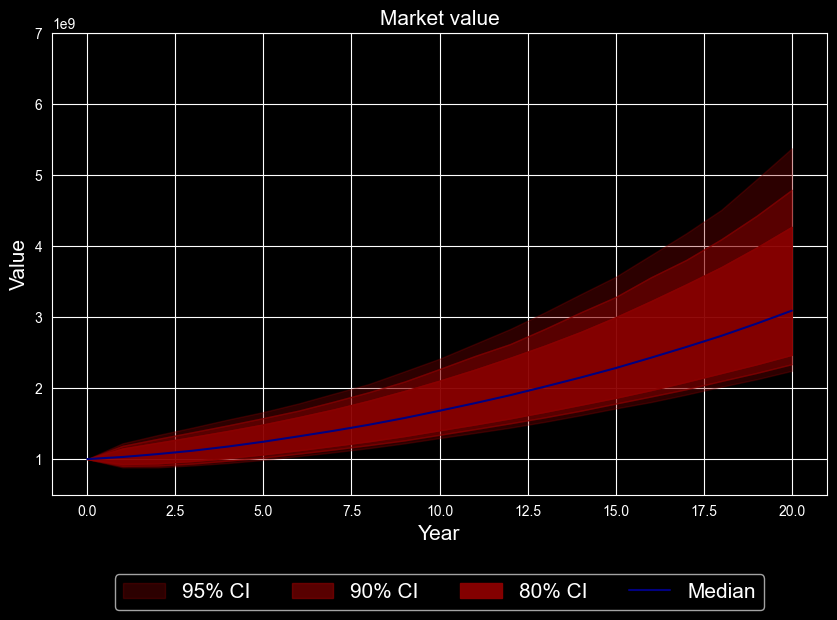

In [281]:
# calculate percentiles
percentiles = np.percentile(port_value_with_investment_yearly, [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)
percentiles_old = np.percentile(init_port_value_yearly, [2.5, 5, 10, 50, 90, 95, 97.5], axis=0)

"""
Plot fan chart
"""

fig, ax = plt.subplots(figsize=(10, 6))

fan_chart(yearly_time_points,
          percentiles,
          color='darkred',
          color_median='navy',
          labels=['95% CI', '90% CI', '80% CI', 'Median'],
          ax=ax)

ax.set_xlabel("Year", size=15)
ax.set_ylabel("Value", size=15)
ax.set_title("Market value", size=15)
ax.set_ylim([500 * 1e6, 7_000 * 1e6])

ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=5, fontsize=15);

Text(0.5, 1.0, 'Portfolio value at the end of 20 years')

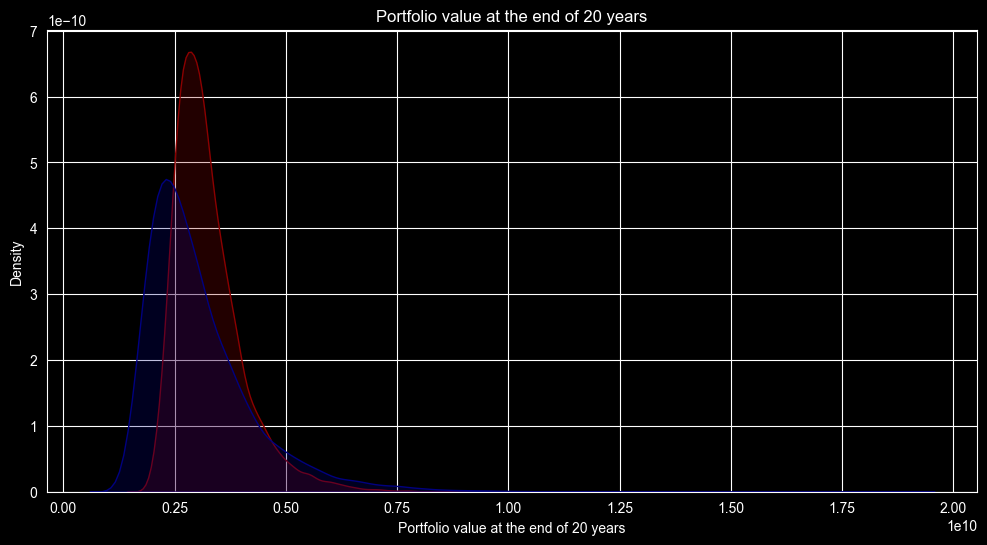

In [282]:
"""
Density plots at 10 and 20 years comparing new and old portfolio
"""

fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(port_value_with_investment_yearly[:, -1],
            fill=True,
            color='darkred',
            label='Portfolio with Real Estate Investment',
            ax=ax)

sns.kdeplot(init_port_value_yearly[:, -1],
            fill=True,
            color='navy',
            label='Initial Portfolio without Real Estate Investment',
            ax=ax)
# labels
ax.set_xlabel('Portfolio value at the end of 20 years')
ax.set_ylabel('Density')
ax.set_title('Portfolio value at the end of 20 years')

In [83]:
init_port_value_yearly[:, -1].mean() / wealth

np.float64(3.0867677379175644)

In [84]:
port_value_with_investment_yearly[:, -1].mean() / wealth

np.float64(3.526924297267843)

Text(0.5, 1.0, 'Portfolio value at the end of 10 years')

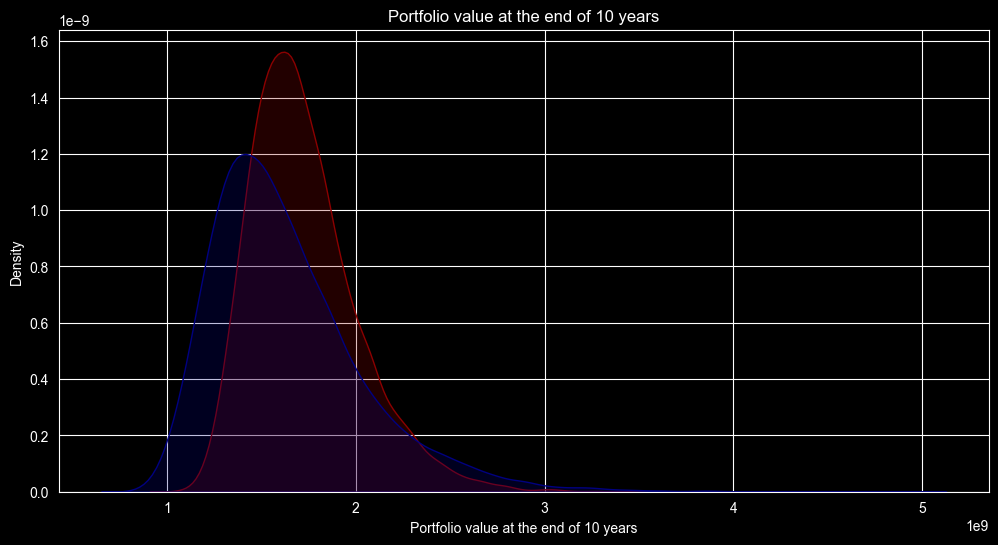

In [283]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.kdeplot(port_value_with_investment_yearly[:, 10],
            fill=True,
            color='darkred',
            label='Portfolio with Real Estate Investment',
            ax=ax)

sns.kdeplot(init_port_value_yearly[:, 10],
            fill=True,
            color='navy',
            label='Initial Portfolio without Real Estate Investment',
            ax=ax)
# labels
ax.set_xlabel('Portfolio value at the end of 10 years')
ax.set_ylabel('Density')
ax.set_title('Portfolio value at the end of 10 years')

In [ ]:
"""
Return metrics
"""



In [ ]:
# Calculate probability of beating the initial portfolio